# 🎓 Complete Machine Learning Pipeline
### Data Cleaning → Visualisation → Feature Engineering → Model Training → Evaluation

---

> **Dataset:** Student Habits & Academic Performance (1,000 students)  
> **Goal:** Predict a student's exam score using their lifestyle habits  
> **Model:** Linear Regression  

---

## 📋 Table of Contents

| Step | Topic |
|------|-------|
| 1 | Import Libraries |
| 2 | Load and Explore Data |
| 3 | Clean the Data |
| 4 | Visualise the Data |
| 5 | What is Scikit-learn? |
| 6 | Encode Categorical Columns |
| 7 | Feature Scaling |
| 8 | Train-Test Split |
| 9 | What is Linear Regression? |
| 10 | Train the Model |
| 11 | Evaluate the Model |
| 12 | Visualise Predictions |
| 13 | Predict New Students |
| 14 | Summary + Exercises |

---
# Step 1 — Import Libraries
---

We import all the libraries we need at the very top. This is the standard first cell in every data science and machine learning notebook.

**Why at the top?** So anyone reading the notebook immediately knows what tools we are using.

In [ ]:
# ── Data Manipulation ────────────────────────────────────────
import pandas as pd        # for loading and cleaning data
import numpy as np         # for math and array operations

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt   # base charting library
import seaborn as sns             # statistical charts on top of matplotlib

# ── Machine Learning (Scikit-learn) ───────────────────────────
from sklearn.model_selection import train_test_split    # split data

from sklearn.linear_model   import LinearRegression 
    # our first model
from sklearn.linear_model   import Ridge                # for Ridge regression
from sklearn.linear_model   import Lasso 
               # for Lasso regression
from sklearn.preprocessing  import PolynomialFeatures  
 # for polynomial regression
from sklearn.preprocessing  import OrdinalEncoder        # for ordinal encoding
from sklearn.metrics        import (mean_absolute_error,
                                    mean_squared_error,
                                    r2_score)            # evaluation
from sklearn.preprocessing  import StandardScaler       # feature scaling

# ── Settings ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # hide minor warnings
%matplotlib inline                 
sns.set_theme(style='whitegrid', font_scale=1.1)

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
# Step 2 — Load and Explore the Data
---

**Two key terms to know before we start:**

- **Feature (X)** = the inputs to the model — everything we know about a student (age, study hours, sleep, etc.)
- **Target (y)** = what we want to predict — the exam score

Our job is to teach the model: *given these features, predict this target.*

In [125]:
# Load the CSV file into a DataFrame
df = pd.read_csv('student_habits_performance.csv')

print(f'Loaded: {df.shape[0]} students, {df.shape[1]} columns')

Loaded: 1000 students, 16 columns


In [126]:
# See the first 5 rows — get a feel for the data
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [127]:
# Overview: column names, data types, non-null counts
# Look for columns where non-null < 1000 — those have missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [128]:
# Statistical summary of all numeric columns
# Look at min/max — any impossible values?
# Look at mean — does it make sense?
df.describe().round(2)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.50,3.55,2.51,1.82,84.13,6.47,3.04,5.44,69.60
std,2.31,1.47,1.17,1.08,9.40,1.23,2.03,2.85,16.89
min,17.00,0.00,0.00,0.00,56.00,3.20,0.00,1.00,18.40
25%,18.75,2.60,1.70,1.00,78.00,5.60,1.00,3.00,58.48
50%,20.00,3.50,2.50,1.80,84.40,6.50,3.00,5.00,70.50
75%,23.00,4.50,3.30,2.52,91.02,7.30,5.00,8.00,81.32
max,24.00,8.30,7.20,5.40,100.00,10.00,6.00,10.00,100.00


In [129]:
# Count missing values in each column
# Zero means no missing — good!
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [130]:
# Check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


### 📝 What We Found

| Column | Issue |
|--------|-------|
| `parental_education_level` | 91 missing values (9.1%) |
| All other columns | Complete — zero missing |
| Duplicate rows | None |
| Exam score range | 18.4 to 100 — valid |
| Impossible values | None found |

This is already a clean dataset — we only need to fix the 91 missing values and drop the ID column.

---
# Step 3 — Clean the Data
---

Even though this dataset is mostly clean, we still do three things:
1. Make a working copy — never change the original
2. Fill the 91 missing values
3. Drop the student_id column — it is just an ID, not a useful feature

In [131]:
# Always work on a copy — never modify the original
# If something goes wrong, df still has the original data
df_clean = df.copy()

In [132]:
# Fill missing parental_education_level with 'Unknown'
# We use 'Unknown' instead of dropping rows — we keep all 1000 students
df_clean['parental_education_level'] = df_clean['parental_education_level'].fillna('Unknown')

In [133]:
# Drop student_id — it is just an identifier, not a real feature
# The model would learn nothing useful from 'S1000', 'S1001', etc.
df_clean = df_clean.drop(columns=['student_id'])

In [134]:
# Verify — all missing values should be gone now
print('Missing values remaining:', df_clean.isnull().sum().sum())
print('Shape:', df_clean.shape)

Missing values remaining: 0
Shape: (1000, 15)


---
# Step 4 — Visualise the Data
---

**This step is not optional.** Before building any model, always visualise your data.

Visualisation tells us:
- Which features are most related to exam score (so we know what to expect from the model)
- The shape of distributions (normal? skewed?)
- Any patterns the model should pick up

**Rule:** If you skip visualisation and go straight to training, you are flying blind.

### Chart 1 — Exam Score Distribution
What does the target variable look like? Is it normally distributed or skewed?

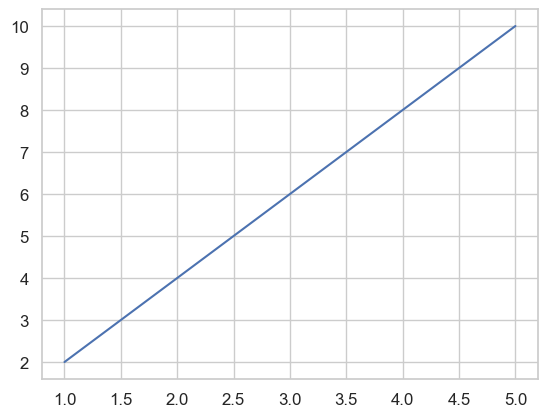

In [135]:
x=[1,2,3,4,5]
y=[2,4,6,8,10]
plt.plot(x,y)

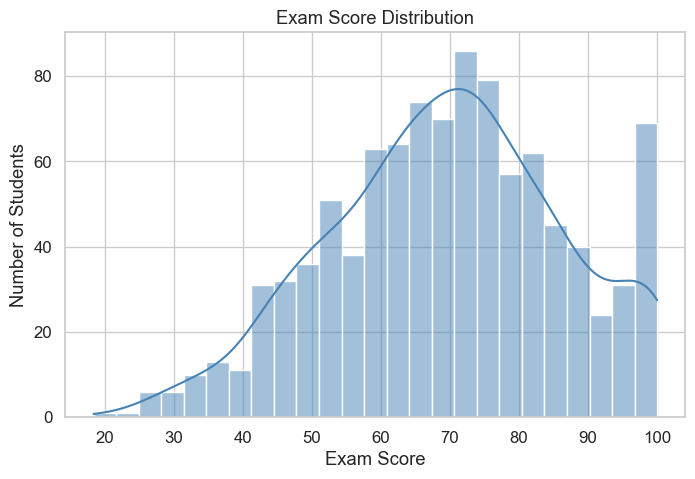

In [136]:
# Histogram of exam score
# kde=True adds a smooth curve showing the overall shape
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='exam_score', bins=25, kde=True, color='steelblue')
plt.title('Exam Score Distribution')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')
plt.show()

### Chart 2 — The Most Important Relationship
Study hours vs exam score — this is what we are predicting. Let's see how strong the relationship is visually.

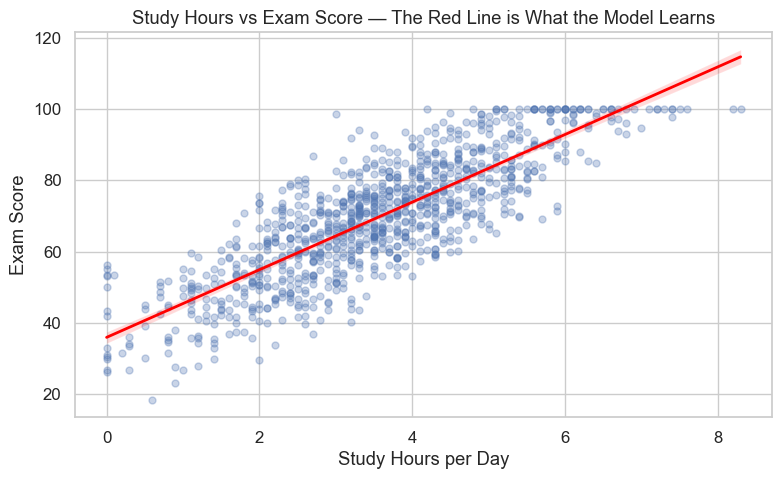

In [137]:
# Scatter plot with trend line — the core relationship
# regplot draws both the scatter dots and the best-fit line
plt.figure(figsize=(9, 5))
sns.regplot(data=df_clean, x='study_hours_per_day', y='exam_score',
            scatter_kws={'alpha': 0.3, 's': 25},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Study Hours vs Exam Score — The Red Line is What the Model Learns')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.show()

### Chart 3 — Correlation Heatmap
Which features are most related to exam score? The heatmap shows all relationships at once.

**Look at the exam_score row** — the greenest cell tells you the most useful feature for prediction.

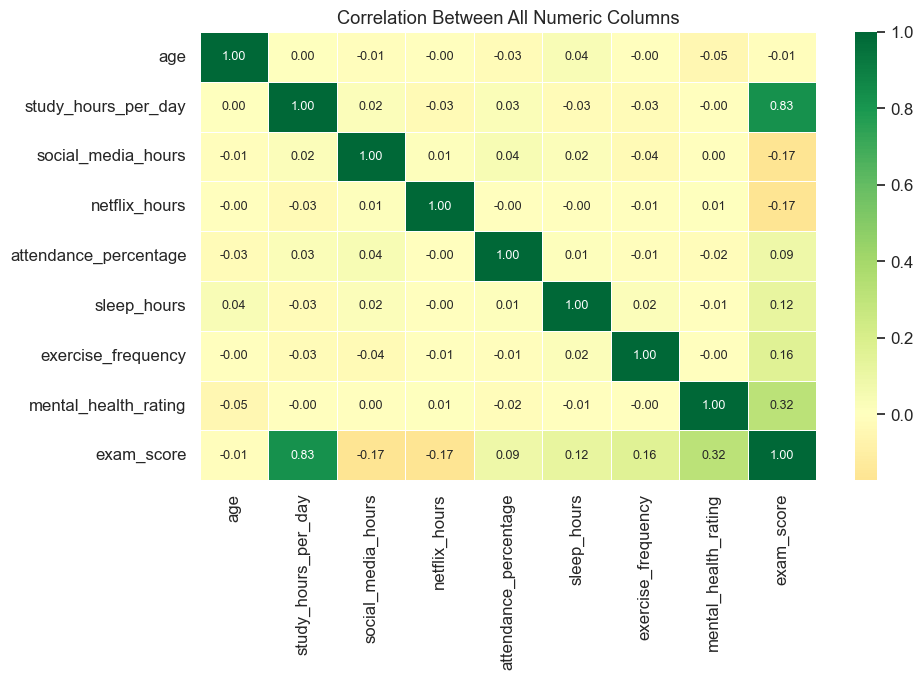

In [138]:
# Correlation heatmap
# corr() calculates how strongly each column relates to every other column
# Values range from -1 (opposite) to +1 (same direction)
plt.figure(figsize=(10, 7))
numeric_cols = df_clean.select_dtypes(include='number').columns
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Between All Numeric Columns')
plt.tight_layout()
plt.show()

### Chart 4 — Box Plots by Category
How does exam score vary by different groups? This tells us which categorical features might be useful.

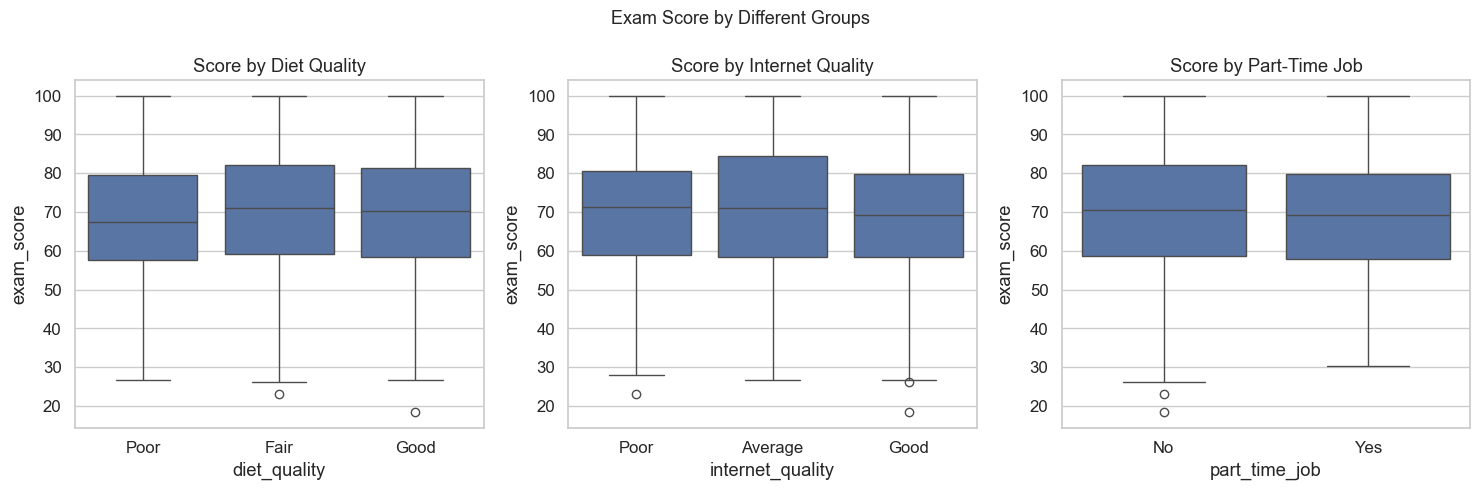

In [139]:
# Box plots — exam score by 3 different categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_clean, x='diet_quality',   y='exam_score', order=['Poor','Fair','Good'], ax=axes[0])
sns.boxplot(data=df_clean, x='internet_quality', y='exam_score', order=['Poor','Average','Good'], ax=axes[1])
sns.boxplot(data=df_clean, x='part_time_job',  y='exam_score', ax=axes[2])

axes[0].set_title('Score by Diet Quality')
axes[1].set_title('Score by Internet Quality')
axes[2].set_title('Score by Part-Time Job')

plt.suptitle('Exam Score by Different Groups', fontsize=13)
plt.tight_layout()
plt.show()

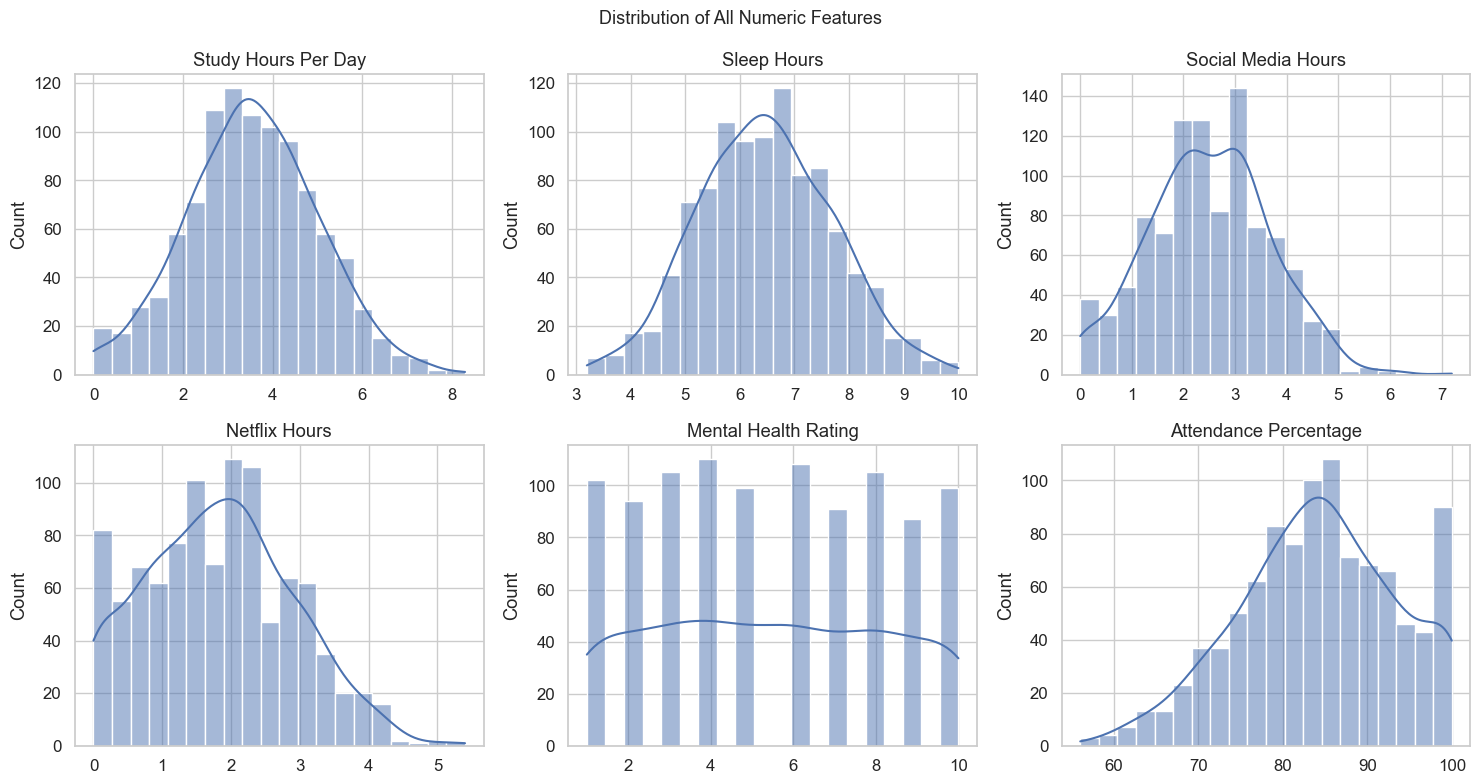

In [140]:
# Distribution of all numeric features
# This helps us understand what range of values each feature has
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['study_hours_per_day','sleep_hours','social_media_hours',
            'netflix_hours','mental_health_rating','attendance_percentage']

for i, col in enumerate(features):
    row, c = divmod(i, 3)
    sns.histplot(data=df_clean, x=col, bins=20, kde=True, ax=axes[row][c])
    axes[row][c].set_title(col.replace('_',' ').title())
    axes[row][c].set_xlabel('')

plt.suptitle('Distribution of All Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

---
# Step 5 — What is Scikit-learn?
---

## The Most Important ML Library in Python

**Scikit-learn** (imported as `sklearn`) is a free Python library that contains ready-to-use machine learning algorithms.

It was created in **2007** by David Cournapeau as a Google Summer of Code project and is now the world standard for ML.

---

## Why Do We Need It?

Without Scikit-learn, building a Linear Regression model requires writing pages of complex mathematics.

**Without Scikit-learn:**
```python
# Pages of matrix math...
X_b = np.c_[np.ones((len(X), 1)), X]
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
# ... many more lines
```

**With Scikit-learn:**
```python
model = LinearRegression()    # create
model.fit(X_train, y_train)   # train
model.predict(X_test)         # predict
# Done in 3 lines!
```

---

## The Universal Scikit-learn Pattern

Every single model in Scikit-learn — whether Linear Regression, Random Forest, SVM, or KNN — always follows the **exact same 3 steps**:

```
Step 1:  model = ModelName()          ← Create
Step 2:  model.fit(X_train, y_train)  ← Train (learn)
Step 3:  model.predict(X_test)        ← Predict
```

Learn this pattern once. It works for every model you will ever use.

---

## What Scikit-learn Contains

| Category | Examples |
|----------|----------|
| **Regression** | LinearRegression, Ridge, Lasso, RandomForestRegressor |
| **Classification** | LogisticRegression, DecisionTree, RandomForest, SVM, KNN |
| **Clustering** | KMeans, DBSCAN |
| **Preprocessing** | StandardScaler, LabelEncoder, OneHotEncoder |
| **Model Selection** | train_test_split, cross_val_score, GridSearchCV |
| **Metrics** | accuracy_score, r2_score, mean_absolute_error |

---

## Scikit-learn in AI

- Build and test ML models before moving to deep learning
- Preprocess data for neural networks
- Evaluate model performance
- Select the best features
- Compare multiple algorithms easily

---
# Step 6 — Encode Categorical Columns
---

## Why Encoding Is Necessary

Machine learning models are **pure mathematics**. They only understand numbers. They cannot process words like `'Male'`, `'Good'`, or `'Yes'`.

We must convert every text column into numbers before training. This is called **encoding**.

## One-Hot Encoding — The Standard Method

One-hot encoding creates a new binary (0 or 1) column for each unique category value.

**Example — gender column:**
```
Before:         After one-hot encoding:
gender          gender_Male    gender_Other
Female    →     0              0
Male      →     1              0
Other     →     0              1
Female    →     0              0
```

Why `drop_first=True`? Because if gender is not Male and not Other, it MUST be Female. We do not need a Female column — it is redundant. This avoids the **dummy variable trap**.

In [141]:
# Make a copy for ML preparation
df_ml = df_clean.copy()

# Find which columns are still text (object dtype)
text_cols = df_ml.select_dtypes(include='object').columns.tolist()

print('Columns that need encoding:', text_cols)

Columns that need encoding: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [142]:
# One-hot encode all text columns using pandas
# drop_first=True removes the first dummy column per group (avoids redundancy)

df_ml = pd.get_dummies(df_ml, columns=text_cols, drop_first=True)

print(f'Columns before encoding : {len(df_clean.columns)}')
print(f'Columns after encoding  : {len(df_ml.columns)}')
print(f'New shape               : {df_ml.shape}')

Columns before encoding : 15
Columns after encoding  : 20
New shape               : (1000, 20)


In [143]:
# See the new column names after encoding
# Notice: 'gender' is gone, replaced by 'gender_Male' and 'gender_Other'
print('All columns after encoding:')
print(df_ml.columns.tolist())

All columns after encoding:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score', 'gender_Male', 'gender_Other', 'part_time_job_Yes', 'diet_quality_Good', 'diet_quality_Poor', 'parental_education_level_High School', 'parental_education_level_Master', 'parental_education_level_Unknown', 'internet_quality_Good', 'internet_quality_Poor', 'extracurricular_participation_Yes']


In [144]:
# Preview encoded data — all values are now numbers
df_ml.head(3)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,parental_education_level_Unknown,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,False,False,False,False,False,False,True,False,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,False,False,False,True,False,True,False,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,True,False,False,False,True,True,False,False,False,True,False


### Separate Features (X) and Target (y)

This is a fundamental step in every ML workflow:

- **X (features)** = everything the model uses as INPUT — all columns except exam_score
- **y (target)** = what the model predicts as OUTPUT — the exam_score column

Think of X as the question paper and y as the answer key.

In [145]:
# X = all features (all columns EXCEPT the target)
X = df_ml.drop(columns=['exam_score'])

# y = target (the column we want to predict)
y = df_ml['exam_score']

# Clip y to 0-100 range — prevents model predicting above 100
y = y.clip(0, 100)

print(f'X (features) shape : {X.shape}  → {X.shape[1]} features for each student')
print(f'y (target)   shape : {y.shape}  → one score per student')

X (features) shape : (1000, 19)  → 19 features for each student
y (target)   shape : (1000,)  → one score per student


---
# Step 7 — Feature Scaling
---

## Why Scale Features?

Different columns have very different value ranges:

```
age                   →  17  to  24      (range of 7)
attendance_percentage →  56  to  100     (range of 44)
study_hours_per_day   →  0   to  8.3     (range of 8.3)
mental_health_rating  →  1   to  10      (range of 9)
```

Without scaling, the model might think attendance (0-100) is more important than study hours (0-8) just because its numbers are bigger — even if study hours is actually more informative.

**StandardScaler** solves this by converting every column so it has:
- Mean = 0
- Standard Deviation = 1

After scaling, all columns are on the same level. The model judges them fairly.

## IMPORTANT: Split BEFORE Scaling

We split data first, then scale. Why?
- The scaler must learn statistics (mean, std) from TRAINING data only
- If we scale on all data first, test data leaks into training — **data leakage**
- `fit_transform` on training = learn + apply
- `transform` on test = apply only (no learning from test data)

---
# Step 8 — Train-Test Split
---

## Why Do We Split the Data?

Imagine you are a teacher. You give students 1000 practice problems. On exam day, you give them **new problems they have never seen**.

Machine learning works the same way:
- **Training data (80%)** = practice problems — the model learns from these
- **Test data (20%)** = exam problems — we check performance on these

If we test on the same data we trained on, we would not know if the model truly learned or just memorised. The test set must stay completely separate until evaluation.

```
1000 students
     ↓
train_test_split(test_size=0.2)
     ↓
Training: 800 students → model learns
Test:     200 students → we evaluate
```

In [146]:
# Split FIRST — before any scaling
# test_size=0.2 means 20% goes to test, 80% to training
# random_state=42 makes the split identical every time you run the notebook

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Total  : {len(X)}')
print(f'Train  : {len(X_train)}  (80%)')
print(f'Test   : {len(X_test)}   (20%)')

Total  : 1000
Train  : 800  (80%)
Test   : 200   (20%)


In [147]:
# Now scale — AFTER splitting
scaler = StandardScaler()

# fit_transform on TRAINING data: learn mean/std from training, then apply

X_train_scaled = scaler.fit_transform(X_train)

# transform on TEST data: apply the SAME mean/std learned from training
# We do NOT call fit_transform on test — that would cause data leakage!
  
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print('Scaling done!')
print(f'study_hours mean after scaling: {X_train_scaled["study_hours_per_day"].mean():.4f}  (should be ~0.0)')
print(f'study_hours std  after scaling: {X_train_scaled["study_hours_per_day"].std():.4f}   (should be ~1.0)')

Scaling done!
study_hours mean after scaling: -0.0000  (should be ~0.0)
study_hours std  after scaling: 1.0006   (should be ~1.0)


---
# Step 9 — What is Linear Regression?
---

## The Concept

Linear Regression finds the **best straight line** through data points that predicts the target value.

You already saw this line in the scatter plot — the red trend line. That line IS Linear Regression.

## The Equation

```
exam_score = (w1 × study_hours)
           + (w2 × sleep_hours)
           + (w3 × social_media_hours)
           + (w4 × mental_health_rating)
           + ... (one weight per feature)
           + b   (bias/intercept)
```

- **w1, w2, w3...** = weights — how much each feature contributes
- **b** = bias — the baseline score when all features are zero
- The model **learns** the best values for all weights from training data

## When to Use Linear Regression

✅ Use when:
- Your target is a **continuous number** (score, price, temperature, salary)
- You suspect a **linear relationship** between features and target
- You want a **simple, interpretable** model

❌ Do NOT use when:
- Your target is a category (pass/fail, spam/not spam) — use Logistic Regression
- The relationship is highly non-linear (use Random Forest or Neural Networks)

## In AI
- Predicting house prices from size and location
- Predicting student exam scores from study habits
- Predicting sales from advertising budget
- Predicting hospital patient stay duration

---
# Step 10 — Train the Model
---

Three lines. That is all it takes. Remember the Scikit-learn pattern:
1. Create
2. Train (.fit)
3. Predict

In [148]:
# Step 1 — Create the model object
# At this point the model is empty — it has not seen any data yet
model = LinearRegression()

print('Model created — not trained yet')

Model created — not trained yet


In [149]:
# Step 2 — Train the model
# .fit() is where ALL the learning happens
# The model reads X_train and y_train and finds the best weights
# This is the most important line in machine learning


model.fit(X_train_scaled, y_train)

print('✅ Model trained!')

✅ Model trained!


In [150]:
# Step 3 — Make predictions on the TEST set
# These are 200 students the model has NEVER seen before

y_pred = model.predict(X_test_scaled)

# Clip predictions to valid range — linear regression can predict above 100
y_pred = np.clip(y_pred, 0, 100)

print('✅ Predictions made!')
print(f'\nFirst 5 actual scores    : {y_test.values[:5].round(1)}')
print(f'First 5 predicted scores : {y_pred[:5].round(1)}')

✅ Predictions made!

First 5 actual scores    : [64.2 72.7 79.  79.5 58.2]
First 5 predicted scores : [66.3 75.2 77.8 73.4 61.1]


---
# Step 11 — Evaluate the Model
---

## Three Evaluation Metrics

| Metric | What it measures | Perfect value |
|--------|-----------------|---------------|
| **MAE** | Average absolute error in points | 0 |
| **RMSE** | Average error — penalises big mistakes more | 0 |
| **R² Score** | What % of score variation does the model explain? | 1.0 |

**R² (R-squared) is the most important one:**
- R² = 0.90 → model explains 90% of variation in exam scores
- R² = 1.00 → perfect model
- R² = 0.00 → model is no better than just predicting the average every time
- R² < 0.00 → model is worse than guessing the average

In [151]:
# Calculate all three metrics

mae  = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2   = r2_score(y_test, y_pred)



print('=' * 48)
print('         MODEL EVALUATION RESULTS')
print('=' * 48)
print(f'  MAE   (Mean Absolute Error)  : {mae:.2f} points')
print(f'  RMSE  (Root Mean Sq Error)   : {rmse:.2f} points')
print(f'  R²    (R-Squared Score)      : {r2:.4f}')
print('=' * 48)
print(f'  Model explains {r2*100:.1f}% of variation in exam scores')

         MODEL EVALUATION RESULTS
  MAE   (Mean Absolute Error)  : 4.14 points
  RMSE  (Root Mean Sq Error)   : 5.12 points
  R²    (R-Squared Score)      : 0.8978
  Model explains 89.8% of variation in exam scores


### Overfitting Check

**Overfitting** happens when a model performs very well on training data but poorly on test data. It means the model memorised the training data instead of learning general patterns.

- If R² train ≈ R² test → model is generalising well ✅
- If R² train >> R² test → model is overfitting ⚠️

In [152]:
# Compare training vs test performance
y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.clip(y_train_pred, 0, 100)


r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_pred)



print(f'R² on Training data : {r2_train:.4f}')
print(f'R² on Test data     : {r2_test:.4f}')
print(f'Difference          : {abs(r2_train - r2_test):.4f}')
print()
if abs(r2_train - r2_test) < 0.05:
    print('✅ Scores are close — model is NOT overfitting')
else:
    print('⚠️  Big gap — model may be overfitting')

R² on Training data : 0.9122
R² on Test data     : 0.8978
Difference          : 0.0143

✅ Scores are close — model is NOT overfitting


### Feature Importance — What Did the Model Learn?

Each feature has a **coefficient (weight)**:
- **Positive coefficient** → more of this feature = higher predicted score
- **Negative coefficient** → more of this feature = lower predicted score
- **Larger absolute value** → more important feature

In [153]:
print(model.coef_)

print(model.intercept_)

[ 1.20528104e-01  1.41447357e+01 -3.13381550e+00 -2.53439971e+00
  1.35968482e+00  2.42158579e+00  2.65623563e+00  5.56430178e+00
  6.70169046e-02  1.65821082e-01  1.52382721e-01 -4.63961899e-01
 -2.12683927e-01 -2.21340918e-01 -2.60140023e-01 -2.44692949e-01
 -1.10545655e-01 -1.01439716e-02 -5.18592869e-02]
69.82737499999999


In [154]:
# Show all feature coefficients sorted by importance
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)



print('Top 5 features that HELP exam scores:')
print(coef_df.head())
print()
print('Top 5 features that HURT exam scores:')
print(coef_df.tail())

Top 5 features that HELP exam scores:
                 Feature  Coefficient
1    study_hours_per_day    14.144736
7   mental_health_rating     5.564302
6     exercise_frequency     2.656236
5            sleep_hours     2.421586
4  attendance_percentage     1.359685

Top 5 features that HURT exam scores:
                             Feature  Coefficient
15  parental_education_level_Unknown    -0.244693
14   parental_education_level_Master    -0.260140
11                 diet_quality_Good    -0.463962
3                      netflix_hours    -2.534400
2                 social_media_hours    -3.133815


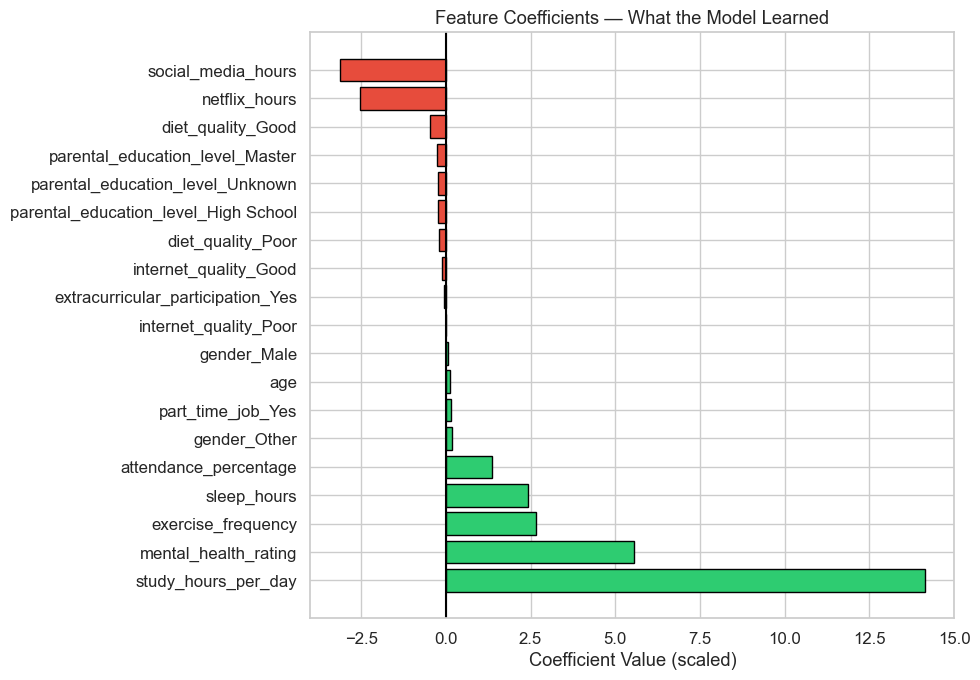

In [155]:
# Visualise coefficients — green=positive, red=negative
plt.figure(figsize=(10, 7))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1.5)
plt.title('Feature Coefficients — What the Model Learned')
plt.xlabel('Coefficient Value (scaled)')
plt.tight_layout()
plt.show()

---
# Step 12 — Visualise the Predictions
---

Numbers alone do not tell the full story. We use three charts to understand how well the model predicts.

### Plot 1 — Actual vs Predicted (The Most Important Plot)

If our model were perfect, every dot would sit exactly on the red diagonal line (predicted = actual).
Dots close to the line = good predictions. Dots far away = large errors.

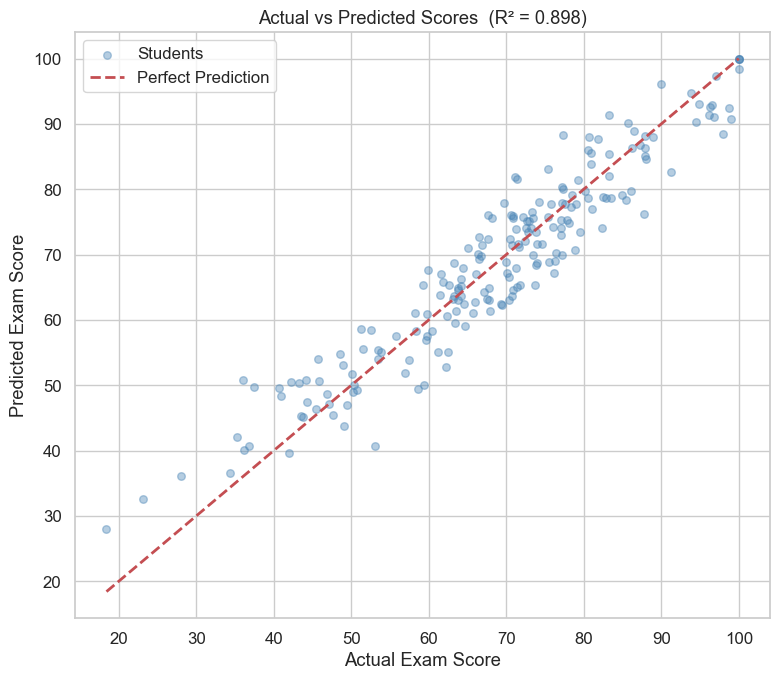

In [156]:
plt.figure(figsize=(8, 7))

# Each dot = one student from the test set
plt.scatter(y_test, y_pred, alpha=0.4, s=30, color='steelblue', label='Students')

# The perfect prediction line — where predicted = actual
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title(f'Actual vs Predicted Scores  (R² = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

### Plot 2 — Residuals Distribution

A **residual** = actual score − predicted score.

A good model has residuals that form a bell shape centered exactly at 0.
- Centered at 0 = model does not systematically over- or under-predict
- Bell shape = errors are random, not patterned

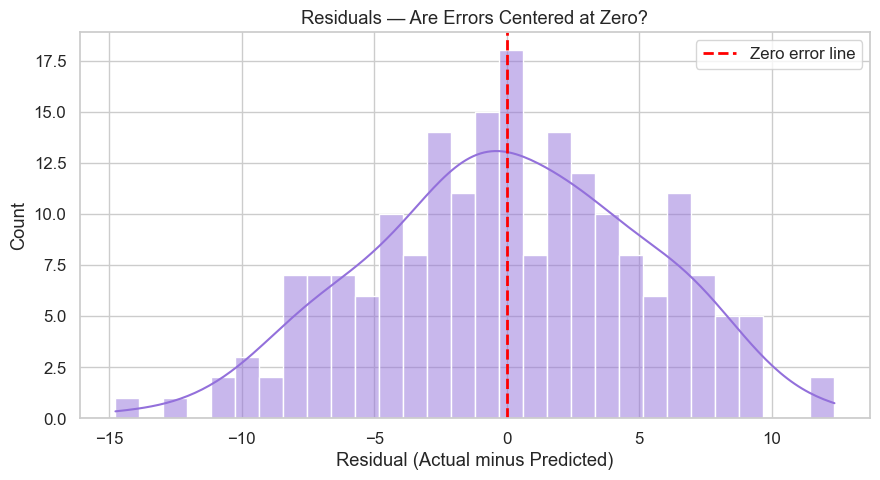

Mean of residuals: 0.006  (ideal = 0.000)


In [157]:
# Calculate residuals
residuals = y_test.values - y_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=30, kde=True, color='mediumpurple')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error line')
plt.xlabel('Residual (Actual minus Predicted)')
plt.ylabel('Count')
plt.title('Residuals — Are Errors Centered at Zero?')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean of residuals: {residuals.mean():.3f}  (ideal = 0.000)')

### Plot 3 — Actual vs Predicted for 20 Students

This gives an intuitive view — for 20 real students, how close was our prediction to reality?

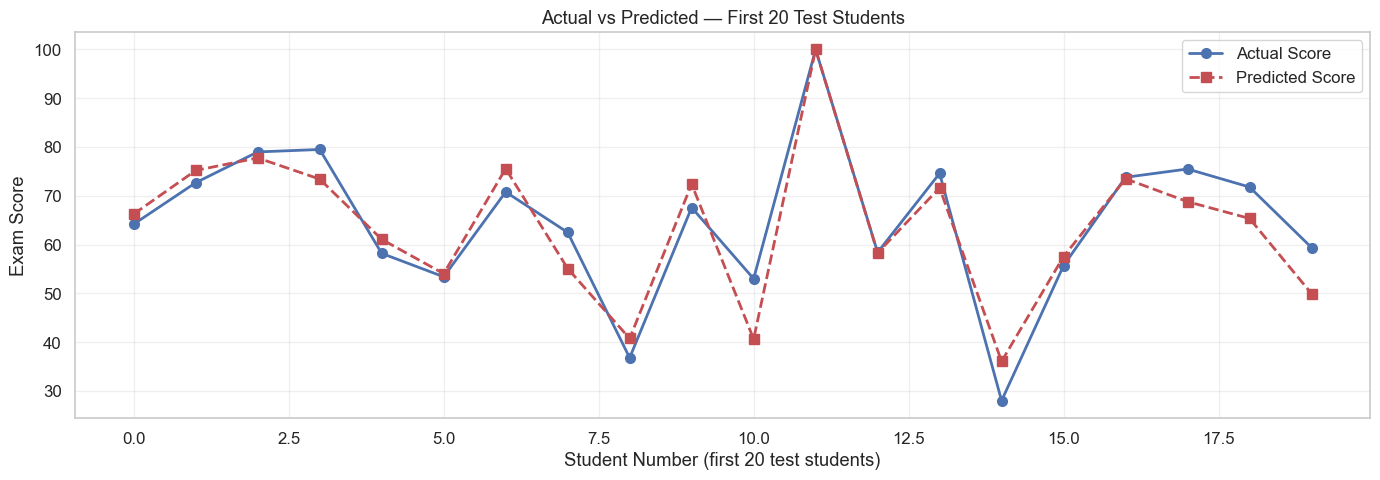

In [158]:
plt.figure(figsize=(14, 5))
x_pos = range(20)

# Blue solid line = actual scores
plt.plot(x_pos, y_test.values[:20], 'bo-', label='Actual Score', linewidth=2, markersize=7)

# Red dashed line = what the model predicted
plt.plot(x_pos, y_pred[:20], 'rs--', label='Predicted Score', linewidth=2, markersize=7)

plt.xlabel('Student Number (first 20 test students)')
plt.ylabel('Exam Score')
plt.title('Actual vs Predicted — First 20 Test Students')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Step 13 — Predict a New Student
---

This is what the whole pipeline was built for — using the trained model to predict the score of a brand new student.

**Important:** The new student data must be:
1. In exactly the same column format as training data
2. Scaled using the SAME scaler (not a new one)

In [159]:
# Create a new student — good habits
new_student = pd.DataFrame([{
    'age'                            : 21,
    'study_hours_per_day'            : 6.0,   # studies 6 hours
    'social_media_hours'             : 1.5,   # low social media
    'netflix_hours'                  : 1.0,   # low netflix
    'attendance_percentage'          : 90.0,  # attends 90% of classes
    'sleep_hours'                    : 7.5,   # sleeps well
    'exercise_frequency'             : 4,     # exercises regularly
    'mental_health_rating'           : 8,     # good mental health
    'gender_Male'                    : 1,     # Male
    'gender_Other'                   : 0,
    'part_time_job_Yes'              : 0,     # no part-time job
    'diet_quality_Good'              : 1,     # good diet
    'diet_quality_Poor'              : 0,
    'parental_education_level_Master': 1,
    'parental_education_level_Unknown':0,
    'internet_quality_Good'          : 1,     # good internet
    'internet_quality_Poor'          : 0,
    'extracurricular_participation_Yes': 1    # joins activities
}])

# Reindex to match training columns exactly
new_student = new_student.reindex(columns=X.columns, fill_value=0)

# Scale using the SAME scaler — not a new one!
new_student_scaled = scaler.transform(new_student)

# Predict and clip to valid range
score1 = np.clip(model.predict(new_student_scaled)[0], 0, 100)
print(f'Good habits student predicted score: {score1:.1f} / 100')

Good habits student predicted score: 100.0 / 100


In [160]:
# Create student 2 — poor habits
new_student2 = new_student.copy()
new_student2['study_hours_per_day']    = 1.0    # only 1 hour study
new_student2['social_media_hours']     = 5.0    # heavy social media use
new_student2['mental_health_rating']   = 3      # poor mental health
new_student2['attendance_percentage']  = 65.0   # low attendance
new_student2['sleep_hours']            = 4.5    # poor sleep

new_student2_scaled = scaler.transform(new_student2)
score2 = np.clip(model.predict(new_student2_scaled)[0], 0, 100)

print(f'Student 1 (good habits) : {score1:.1f} / 100')
print(f'Student 2 (poor habits) : {score2:.1f} / 100')
print(f'Difference              : {score1 - score2:.1f} points')

Student 1 (good habits) : 100.0 / 100
Student 2 (poor habits) : 29.3 / 100
Difference              : 70.7 points


---
# Step 14 — Final Summary
---

In [161]:
print('=' * 50)
print('       COMPLETE PIPELINE SUMMARY')
print('=' * 50)
print(f'  Dataset           : {df.shape[0]} students, {df.shape[1]} columns')
print(f'  Features used     : {X.shape[1]}')
print(f'  Training size     : {len(X_train)} students (80%)')
print(f'  Test size         : {len(X_test)} students (20%)')
print(f'  Model             : Linear Regression')
print(f'  MAE               : {mae:.2f} points')
print(f'  RMSE              : {rmse:.2f} points')
print(f'  R² Score          : {r2:.4f}')
print(f'  Variance explained: {r2*100:.1f}%')
print('=' * 50)

       COMPLETE PIPELINE SUMMARY
  Dataset           : 1000 students, 16 columns
  Features used     : 19
  Training size     : 800 students (80%)
  Test size         : 200 students (20%)
  Model             : Linear Regression
  MAE               : 4.14 points
  RMSE              : 5.12 points
  R² Score          : 0.8978
  Variance explained: 89.8%


In [162]:
import joblib

# ── Save ─────────────────────────────────────────────────────
save_data = {
    'model'  : model,
    'scaler' : scaler,
    'columns': list(X.columns)
}

joblib.dump(save_data, 'student_model.joblib')

print('Model saved!')

Model saved!


In [163]:
# ── Load ─────────────────────────────────────────────────────
saved = joblib.load('student_model.joblib')

model   = saved['model']
scaler  = saved['scaler']
columns = saved['columns']

print('Model loaded!')

Model loaded!


---
# Bonus Step — Ordinal Encoding vs One-Hot Encoding
---

## What We Did Before (One-Hot Encoding)

When we encoded categorical columns, we used **One-Hot Encoding** where each category becomes its own 0/1 column.

For example, `diet_quality` (Poor / Fair / Good) became:

| diet_quality_Fair | diet_quality_Good |
|-------------------|-------------------|
| 1 | 0 | ← Fair diet
| 0 | 1 | ← Good diet
| 0 | 0 | ← Poor diet (the dropped baseline)

## The Problem With One-Hot for Ordered Categories

Some categories have a **natural order**. Good diet is better than Fair, which is better than Poor.
One-hot encoding **ignores this order** — it treats the three categories as completely independent.

**Ordinal Encoding** assigns numbers that respect the order:
- Poor → 0
- Fair → 1
- Good → 2

The model now knows Good (2) > Fair (1) > Poor (0).

## Which Columns Have an Order?

| Column | Natural Order? | Best Encoding |
|--------|---------------|---------------|
| `diet_quality` | Poor < Fair < Good | **Ordinal** |
| `internet_quality` | Poor < Average < Good | **Ordinal** |
| `parental_education_level` | High School < Bachelor < Master | **Ordinal** |
| `gender` | No order | **One-Hot** |
| `part_time_job` | No order (Yes/No) | **One-Hot or Binary** |
| `extracurricular_participation` | No order (Yes/No) | **One-Hot or Binary** |

> **Key Rule:** Use Ordinal for categories that have a meaningful rank. Use One-Hot for categories with no order.

Let us retrain linear regression with Ordinal Encoding for the ordered columns and compare the results!


In [164]:
# ── Step 1: Ordinal encode the 3 ordered columns ─────────────────────────

# Start fresh from the cleaned data
df_ord = df_clean.copy()

# Define the order for each column — from lowest to highest
ordinal_features = ['diet_quality', 'internet_quality', 'parental_education_level']




ordinal_orders = [
    ['Poor', 'Fair', 'Good'],                                   # diet_quality
    ['Poor', 'Average', 'Good'],                                # internet_quality
    ['Unknown', 'High School', 'Bachelor', 'Master']            # parental_education_level
]

# Create the OrdinalEncoder with our custom orders
ord_encoder = OrdinalEncoder(categories=ordinal_orders)

 
# Apply it — replaces text with numbers (0, 1, 2 ...)
df_ord[ordinal_features] = ord_encoder.fit_transform(df_ord[ordinal_features])

print('Ordinal encoding done!')
print()
print('diet_quality mapping      :', dict(zip(['Poor','Fair','Good'], [0,1,2])))
print('internet_quality mapping  :', dict(zip(['Poor','Average','Good'], [0,1,2])))
print('parental_education mapping:', dict(zip(['Unknown','High School','Bachelor','Master'], [0,1,2,3])))


Ordinal encoding done!

diet_quality mapping      : {'Poor': 0, 'Fair': 1, 'Good': 2}
internet_quality mapping  : {'Poor': 0, 'Average': 1, 'Good': 2}
parental_education mapping: {'Unknown': 0, 'High School': 1, 'Bachelor': 2, 'Master': 3}


In [165]:
# ── Step 2: One-hot encode remaining non-ordered text columns ────────────
# These have no natural order, so one-hot is still correct

nominal_features = ['gender', 'part_time_job', 'extracurricular_participation']
df_ord = pd.get_dummies(df_ord, columns=nominal_features, drop_first=True)

print('One-hot encoding done for gender, part_time_job, extracurricular_participation')
print(f'Total columns now: {df_ord.shape[1]}')
print()
# Notice diet_quality, internet_quality, parental_education_level
# are now numbers instead of binary columns
df_ord.head(3)


One-hot encoding done for gender, part_time_job, extracurricular_participation
Total columns now: 16



,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,1.0,6,3.0,1.0,8,56.2,False,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,2.0,6,1.0,1.0,8,100.0,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,0.0,1,1.0,0.0,1,34.3,True,False,False,False


In [166]:
# ── Step 3: Prepare X and y ──────────────────────────────────────────────

X_ord = df_ord.drop(columns=['exam_score'])
y_ord = df_ord['exam_score'].clip(0, 100)

print(f'X shape (ordinal): {X_ord.shape}')
print(f'y shape           : {y_ord.shape}')
print()
print('Notice: fewer columns because ordinal columns stay as 1 column each')
print(f'One-hot version had {X.shape[1]} features, ordinal version has {X_ord.shape[1]} features')


X shape (ordinal): (1000, 15)
y shape           : (1000,)

Notice: fewer columns because ordinal columns stay as 1 column each
One-hot version had 19 features, ordinal version has 15 features


In [167]:
# ── Step 4: Split and Scale ──────────────────────────────────────────────

# Same random_state=42 so we compare fairly
X_train_ord, X_test_ord, y_train_ord, y_test_ord = train_test_split(
    X_ord, y_ord, test_size=0.2, random_state=42
)

# Use a NEW scaler (separate from the one-hot scaler)
scaler_ord = StandardScaler()
X_train_ord_scaled = scaler_ord.fit_transform(X_train_ord)
X_test_ord_scaled  = scaler_ord.transform(X_test_ord)

print('Split and scaling done!')
print(f'Train: {len(X_train_ord)} students | Test: {len(X_test_ord)} students')


Split and scaling done!
Train: 800 students | Test: 200 students


In [168]:
# ── Step 5: Train Linear Regression on Ordinal-encoded data ─────────────

model_ord = LinearRegression()
model_ord.fit(X_train_ord_scaled, y_train_ord)

# Predict
y_pred_ord = np.clip(model_ord.predict(X_test_ord_scaled), 0, 100)

# Evaluate
mae_ord  = mean_absolute_error(y_test_ord, y_pred_ord)
rmse_ord = np.sqrt(mean_squared_error(y_test_ord, y_pred_ord))
r2_ord   = r2_score(y_test_ord, y_pred_ord)

print('Results with Ordinal Encoding:')
print(f'  MAE  : {mae_ord:.2f}')
print(f'  RMSE : {rmse_ord:.2f}')
print(f'  R2   : {r2_ord:.4f}')


Results with Ordinal Encoding:
  MAE  : 4.10
  RMSE : 5.06
  R2   : 0.9001


In [169]:
# ── Step 6: Compare Both Encoding Methods Side by Side ──────────────────

print('=' * 55)
print('   ENCODING COMPARISON -- Linear Regression')
print('=' * 55)
print(f'  Metric    | One-Hot Encoding | Ordinal Encoding')
print(f'  ----------|------------------|------------------')
print(f'  MAE       | {mae:>7.2f} points  | {mae_ord:>7.2f} points')
print(f'  RMSE      | {rmse:>7.2f} points  | {rmse_ord:>7.2f} points')
print(f'  R2        | {r2:>7.4f}         | {r2_ord:>7.4f}')
print(f'  Features  | {X.shape[1]:>7}           | {X_ord.shape[1]:>7}')
print('=' * 55)
print()

if r2_ord > r2:
    print(f'Ordinal encoding gave BETTER R2 by {(r2_ord - r2)*100:.2f}%')
    print('   Ordinal features preserve meaningful rank information.')
elif r2 > r2_ord:
    print(f'One-hot encoding gave BETTER R2 by {(r2 - r2_ord)*100:.2f}%')
    print('   Sometimes one-hot gives the model more flexibility.')
else:
    print('Both encodings gave identical results.')

print()
print('Key Takeaway:')
print('   The difference is often small for Linear Regression.')
print('   But always think about whether your categories have an order!')


   ENCODING COMPARISON -- Linear Regression
  Metric    | One-Hot Encoding | Ordinal Encoding
  ----------|------------------|------------------
  MAE       |    4.14 points  |    4.10 points
  RMSE      |    5.12 points  |    5.06 points
  R2        |  0.8978         |  0.9001
  Features  |      19           |      15

Ordinal encoding gave BETTER R2 by 0.22%
   Ordinal features preserve meaningful rank information.

Key Takeaway:
   The difference is often small for Linear Regression.
   But always think about whether your categories have an order!


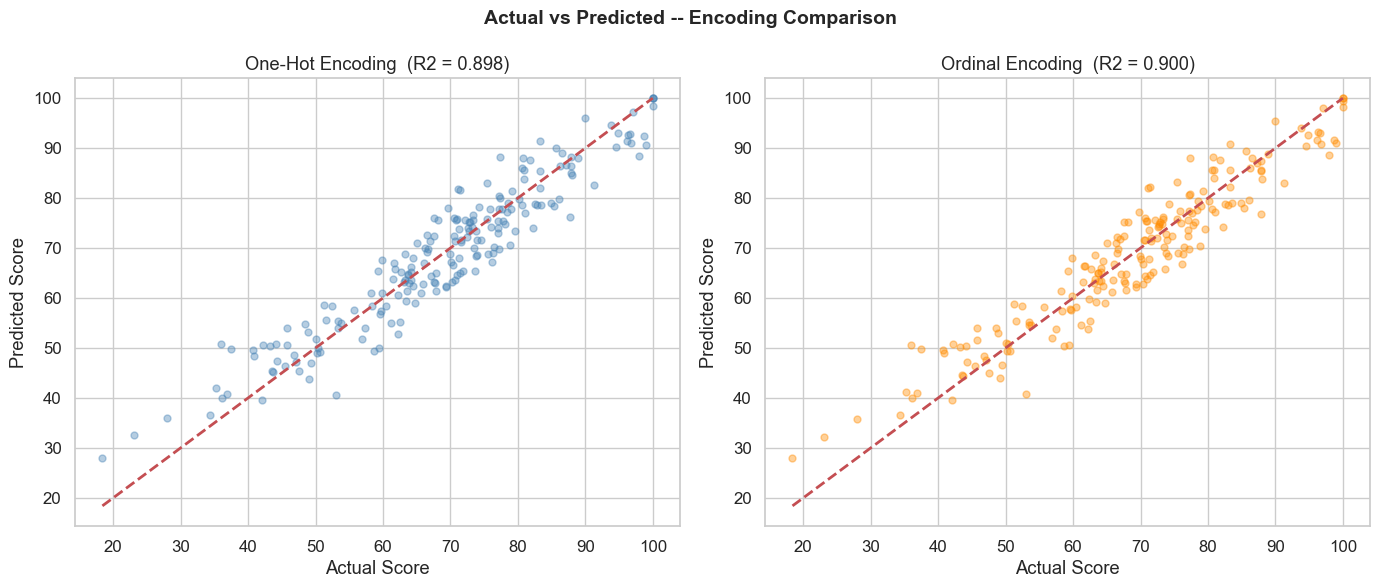

In [170]:
# ── Visual comparison of the two encoding approaches ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# One-Hot predictions
axes[0].scatter(y_test, y_pred, alpha=0.4, s=25, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2)
axes[0].set_title(f'One-Hot Encoding  (R2 = {r2:.3f})')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')

# Ordinal predictions
axes[1].scatter(y_test_ord, y_pred_ord, alpha=0.4, s=25, color='darkorange')
mn2, mx2 = y_test_ord.min(), y_test_ord.max()
axes[1].plot([mn2, mx2], [mn2, mx2], 'r--', linewidth=2)
axes[1].set_title(f'Ordinal Encoding  (R2 = {r2_ord:.3f})')
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')

plt.suptitle('Actual vs Predicted -- Encoding Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Section 2 — Polynomial Regression
---

## Why Do We Need Polynomial Regression?

Linear Regression assumes the relationship between features and target is a **straight line**.

But real-world relationships are often **curved**!

For example:
- A student sleeping **0 hours** gets a bad score
- A student sleeping **7-8 hours** gets the best score
- A student sleeping **12 hours** (oversleeping) also gets a worse score

This is a **curve** (like an upside-down U), not a straight line.
Linear Regression **cannot capture this**. Polynomial Regression **can**.

---

## How Does It Work?

Polynomial Regression creates **new features by raising existing features to powers**.

If your original feature is `x` (e.g., study hours), it adds:
- `x²` (study_hours squared)
- `x³` (study_hours cubed)
- Cross terms like `x × sleep_hours`

This gives the model the ability to fit **curves** instead of just straight lines.

**The math stays the same** — it is still Linear Regression underneath! We just gave it richer features.

---

## When to Use Polynomial Regression?

Use when:
- Your scatter plot shows a **curved relationship**
- Linear Regression has a **low R²** and the data could fit better with curves

Be careful:
- Higher degrees (3, 4, 5...) can cause **overfitting**
- Always check if training R² is much higher than test R² — that is a warning sign
- Usually **degree=2** is enough for most real datasets

---

## Polynomial Degree — What It Means

| Degree | Shape | Features added |
|--------|-------|----------------|
| 1 | Straight line (same as Linear Regression) | None |
| 2 | Curves (parabola) | x², cross terms |
| 3 | S-curves | x², x³, more cross terms |

We will use **degree=2** — a good balance between power and simplicity.


In [173]:
# ── Step 1: Create polynomial features ───────────────────────────────────
# degree=2 means we create x, x^2, and x*x2 (interaction) terms
# include_bias=False means we don't add a column of 1s (sklearn handles this)

poly = PolynomialFeatures(degree=3, include_bias=False)

# Apply to training data ONLY — then apply same transformation to test

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

print(f'Original number of features : {X_train_scaled.shape[1]}')
print(f'After degree-2 polynomial   : {X_train_poly.shape[1]}')
print()
print('Polynomial features add squared terms and interaction terms.')
print('That is why the number jumps so much!')


Original number of features : 19
After degree-2 polynomial   : 1539

Polynomial features add squared terms and interaction terms.
That is why the number jumps so much!


In [ ]:
print(X_train_poly)

In [174]:
# ── Step 2: Train Polynomial (Linear) Regression ─────────────────────────

# We still use LinearRegression — just on the expanded polynomial feature set
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# Predict
y_pred_poly = np.clip(model_poly.predict(X_test_poly), 0, 100)

# Evaluate
mae_poly  = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly   = r2_score(y_test, y_pred_poly)

print('Polynomial Regression trained!')
print()
print(f'  MAE  : {mae_poly:.2f} points')
print(f'  RMSE : {rmse_poly:.2f} points')
print(f'  R2   : {r2_poly:.4f}')


Polynomial Regression trained!

  MAE  : 11.21 points
  RMSE : 14.88 points
  R2   : 0.1360


In [175]:
# ── Step 3: Check for Overfitting ────────────────────────────────────────
# Polynomial models are more flexible — they can memorise training data

y_train_pred_poly = np.clip(model_poly.predict(X_train_poly), 0, 100)
r2_poly_train = r2_score(y_train, y_train_pred_poly)
r2_poly_test  = r2_score(y_test,  y_pred_poly)

print('Overfitting Check -- Polynomial Regression:')
print(f'  R2 on TRAINING data : {r2_poly_train:.4f}')
print(f'  R2 on TEST data     : {r2_poly_test:.4f}')
print(f'  Gap                 : {abs(r2_poly_train - r2_poly_test):.4f}')
print()

if abs(r2_poly_train - r2_poly_test) > 0.1:
    print('Large gap -- Polynomial model is OVERFITTING!')
    print('   It learned the training data too well and struggles on new data.')
    print('   Solution: Use Ridge or Lasso regression (next section!)')
elif abs(r2_poly_train - r2_poly_test) < 0.05:
    print('Small gap -- no major overfitting.')
else:
    print('Moderate gap -- keep an eye on overfitting.')

print()
# Compare with Linear Regression
y_train_pred_lr = np.clip(model.predict(X_train_scaled), 0, 100)
r2_lr_train = r2_score(y_train, y_train_pred_lr)
print('Comparison:')
print(f'  Linear Regression  -> train R2: {r2_lr_train:.4f}  | test R2: {r2:.4f}')
print(f'  Polynomial Degree2 -> train R2: {r2_poly_train:.4f}  | test R2: {r2_poly:.4f}')


Overfitting Check -- Polynomial Regression:
  R2 on TRAINING data : 1.0000
  R2 on TEST data     : 0.1360
  Gap                 : 0.8640

Large gap -- Polynomial model is OVERFITTING!
   It learned the training data too well and struggles on new data.
   Solution: Use Ridge or Lasso regression (next section!)

Comparison:
  Linear Regression  -> train R2: 0.9122  | test R2: 0.8978
  Polynomial Degree2 -> train R2: 1.0000  | test R2: 0.1360


---
# Section 3 — Ridge Regression
---

## The Problem With Too Many Features (Overfitting)

When we created polynomial features, the number of features jumped from ~18 to hundreds.
With so many features, the model can **memorise** the training data instead of learning patterns.
This is called **overfitting** — great on training data, bad on new data.

---

## What Is Ridge Regression?

Ridge Regression is **Linear Regression with a penalty** to stop the model from overfitting.

The penalty is called **regularization**. It works like this:
1. During training, if a weight (coefficient) becomes too large, Ridge **penalises** it
2. This forces the model to keep all weights small
3. Small weights = simpler model = less overfitting

---

## The Alpha Parameter

Ridge has one key setting: **alpha**, also called regularization strength.

| Alpha Value | Effect |
|-------------|--------|
| alpha = 0 | Same as regular Linear Regression (no penalty) |
| alpha = 1 | Small penalty — slight regularization |
| alpha = 10 | Medium penalty |
| alpha = 100 | Strong penalty — model becomes very simple |
| alpha = very large | Model just predicts the average for everyone |

**How to choose alpha?** We try many values and pick the best one.  
This is called **hyperparameter tuning**.

---

## Ridge vs Linear Regression

- **Linear Regression**: Minimises prediction errors only
- **Ridge Regression**: Minimises prediction errors **AND** penalises large weights

Ridge does NOT eliminate any feature completely — it just makes weights **smaller**.
Compare with Lasso (next section) which can make weights exactly zero.


In [176]:
# ── Step 1: Try multiple alpha values (hyperparameter tuning) ────────────
# We train Ridge with different alpha values and pick the best one

alpha_values = [0.01, 0.1, 1, 10, 50, 100, 200, 500]
results = []

print('Testing different alpha values for Ridge:')
print(f'{"Alpha":>8} | {"Train R2":>10} | {"Test R2":>10} | {"Gap":>8}')
print('-' * 45)

for alpha in alpha_values:
    # Create and train Ridge model with this alpha
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly, y_train)

    y_tr_pred = np.clip(ridge.predict(X_train_poly), 0, 100)
    y_te_pred = np.clip(ridge.predict(X_test_poly),  0, 100)

    r2_tr = r2_score(y_train, y_tr_pred)
    r2_te = r2_score(y_test,  y_te_pred)
    gap   = abs(r2_tr - r2_te)

    results.append({'alpha': alpha, 'r2_train': r2_tr, 'r2_test': r2_te, 'gap': gap})
    print(f'{alpha:>8.2f} | {r2_tr:>10.4f} | {r2_te:>10.4f} | {gap:>8.4f}')

# Pick the alpha that gives highest test R2
best = max(results, key=lambda x: x['r2_test'])
print()
print(f'Best alpha = {best["alpha"]}  (Test R2 = {best["r2_test"]:.4f})')


Testing different alpha values for Ridge:
   Alpha |   Train R2 |    Test R2 |      Gap
---------------------------------------------
    0.01 |     1.0000 |     0.1370 |   0.8630
    0.10 |     1.0000 |     0.1463 |   0.8537
    1.00 |     0.9999 |     0.2232 |   0.7768
   10.00 |     0.9982 |     0.5081 |   0.4901
   50.00 |     0.9926 |     0.7068 |   0.2858
  100.00 |     0.9878 |     0.7662 |   0.2217
  200.00 |     0.9805 |     0.8079 |   0.1726
  500.00 |     0.9649 |     0.8388 |   0.1261

Best alpha = 500  (Test R2 = 0.8388)


In [177]:
# ── Step 2: Train final Ridge model with the best alpha ──────────────────

best_alpha = best['alpha']


model_ridge = Ridge(alpha=best_alpha)

model_ridge.fit(X_train_poly, y_train)

# Predict
y_pred_ridge = np.clip(model_ridge.predict(X_test_poly), 0, 100)

# Evaluate
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

# Overfitting check
y_train_pred_ridge = np.clip(model_ridge.predict(X_train_poly), 0, 100)
r2_ridge_train = r2_score(y_train, y_train_pred_ridge)

print(f'Ridge Regression trained! (alpha = {best_alpha})')
print()
print(f'  MAE          : {mae_ridge:.2f} points')
print(f'  RMSE         : {rmse_ridge:.2f} points')
print(f'  R2 (train)   : {r2_ridge_train:.4f}')
print(f'  R2 (test)    : {r2_ridge:.4f}')
print(f'  Gap          : {abs(r2_ridge_train - r2_ridge):.4f}')


Ridge Regression trained! (alpha = 500)

  MAE          : 5.10 points
  RMSE         : 6.43 points
  R2 (train)   : 0.9649
  R2 (test)    : 0.8388
  Gap          : 0.1261


---
# Section 4 — Lasso Regression
---

## What Is Lasso Regression?

**Lasso** stands for **Least Absolute Shrinkage and Selection Operator**.

Like Ridge, Lasso adds a penalty to stop overfitting.
But Lasso has a **superpower that Ridge does not have**:

> Lasso can shrink some feature weights all the way to **exactly zero**.

This means Lasso **automatically removes** features that are not useful!
It acts like **automatic feature selection** — very powerful when you have many features.

---

## Ridge vs Lasso — The Key Difference

| | Ridge | Lasso |
|--|-------|-------|
| Penalty type | Sum of squared weights (L2) | Sum of absolute weights (L1) |
| Effect on weights | Makes all weights smaller | Can make some weights exactly 0 |
| Feature selection | No — keeps all features | Yes — automatically removes useless features |
| When to use | Many features, all somewhat useful | When you suspect many features are irrelevant |

---

## The Alpha Parameter in Lasso

Same idea as Ridge:
- **Low alpha** — less penalty — more features kept — risk of overfitting
- **High alpha** — strong penalty — more features zeroed out — risk of underfitting

We again find the best alpha by trying many values.

---

## Why Is This Useful?

We started with 18 features. After polynomial transformation, we have hundreds.
Many of those are probably noise. Lasso will identify and eliminate those automatically!


In [178]:
# ── Step 1: Try multiple alpha values for Lasso ──────────────────────────

lasso_alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50]
lasso_results = []

print('Testing different alpha values for Lasso:')
print(f'{"Alpha":>8} | {"Train R2":>10} | {"Test R2":>10} | {"Non-zero weights":>18}')
print('-' * 55)

for alpha in lasso_alphas:
    # max_iter increased to make sure Lasso converges (finds the answer)
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_poly, y_train)

    y_tr_pred = np.clip(lasso.predict(X_train_poly), 0, 100)
    y_te_pred = np.clip(lasso.predict(X_test_poly),  0, 100)

    r2_tr   = r2_score(y_train, y_tr_pred)
    r2_te   = r2_score(y_test,  y_te_pred)
    nonzero = np.sum(lasso.coef_ != 0)  # how many features survived

    lasso_results.append({'alpha': alpha, 'r2_train': r2_tr, 'r2_test': r2_te, 'nonzero': nonzero})
    print(f'{alpha:>8.3f} | {r2_tr:>10.4f} | {r2_te:>10.4f} | {nonzero:>18}')

best_lasso = max(lasso_results, key=lambda x: x['r2_test'])
print()
print(f'Best alpha = {best_lasso["alpha"]}')
print(f'   Test R2          = {best_lasso["r2_test"]:.4f}')
print(f'   Non-zero features = {best_lasso["nonzero"]} out of {X_train_poly.shape[1]}')


Testing different alpha values for Lasso:
   Alpha |   Train R2 |    Test R2 |   Non-zero weights
-------------------------------------------------------
   0.001 |     0.9999 |     0.1692 |                819
   0.010 |     0.9956 |     0.6108 |                707
   0.100 |     0.9655 |     0.8610 |                375
   1.000 |     0.8819 |     0.8536 |                 51
   5.000 |     0.6322 |     0.5979 |                 16
  10.000 |     0.3862 |     0.3607 |                  1
  50.000 |     0.0000 |    -0.0050 |                  0

Best alpha = 0.1
   Test R2          = 0.8610
   Non-zero features = 375 out of 1539


In [179]:
# ── Step 2: Train final Lasso model with best alpha ──────────────────────

best_lasso_alpha = best_lasso['alpha']

model_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
model_lasso.fit(X_train_poly, y_train)

# Predict
y_pred_lasso = np.clip(model_lasso.predict(X_test_poly), 0, 100)

# Evaluate
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso   = r2_score(y_test, y_pred_lasso)

# Count features Lasso actually uses
nonzero_count  = int(np.sum(model_lasso.coef_ != 0))
total_features = len(model_lasso.coef_)

y_train_pred_lasso = np.clip(model_lasso.predict(X_train_poly), 0, 100)
r2_lasso_train = r2_score(y_train, y_train_pred_lasso)

print(f'Lasso Regression trained! (alpha = {best_lasso_alpha})')
print()
print(f'  MAE          : {mae_lasso:.2f} points')
print(f'  RMSE         : {rmse_lasso:.2f} points')
print(f'  R2 (train)   : {r2_lasso_train:.4f}')
print(f'  R2 (test)    : {r2_lasso:.4f}')
print()
print('  Feature Selection by Lasso:')
print(f'     Total polynomial features  : {total_features}')
print(f'     Features kept (non-zero)   : {nonzero_count}')
print(f'     Features eliminated (zero) : {total_features - nonzero_count}')
pct = ((total_features - nonzero_count) / total_features) * 100
print(f'     Lasso removed {pct:.0f}% of features automatically!')


Lasso Regression trained! (alpha = 0.1)

  MAE          : 4.79 points
  RMSE         : 5.97 points
  R2 (train)   : 0.9655
  R2 (test)    : 0.8610

  Feature Selection by Lasso:
     Total polynomial features  : 1539
     Features kept (non-zero)   : 375
     Features eliminated (zero) : 1164
     Lasso removed 76% of features automatically!


---
# Final Comparison — All Models
---

Now let us compare all four regression models we trained:
1. **Linear Regression** — baseline, straight line
2. **Polynomial Regression** — captures curves (degree 2)
3. **Ridge Regression** — polynomial + penalty to control overfitting
4. **Lasso Regression** — polynomial + penalty + automatic feature selection

This side-by-side comparison helps you understand which model works best and why.


In [181]:
# ── Full model comparison table ──────────────────────────────────────────

# Recompute train R2 for linear regression
y_train_lr = np.clip(model.predict(X_train_scaled), 0, 100)
r2_lr_train = r2_score(y_train, y_train_lr)

print('=' * 72)
print('              COMPLETE MODEL COMPARISON')
print('=' * 72)
print(f'  {"Model":<25} | {"MAE":>6} | {"RMSE":>6} | {"R2 Test":>8} | {"R2 Train":>9}')
print('-' * 72)
print(f'  {"Linear Regression":<25} | {mae:>6.2f} | {rmse:>6.2f} | {r2:>8.4f} | {r2_lr_train:>9.4f}')
print(f'  {"Polynomial (degree=2)":<25} | {mae_poly:>6.2f} | {rmse_poly:>6.2f} | {r2_poly:>8.4f} | {r2_poly_train:>9.4f}')
print(f'  {"Ridge":<25} | {mae_ridge:>6.2f} | {rmse_ridge:>6.2f} | {r2_ridge:>8.4f} | {r2_ridge_train:>9.4f}')
print(f'  {"Lasso":<25} | {mae_lasso:>6.2f} | {rmse_lasso:>6.2f} | {r2_lasso:>8.4f} | {r2_lasso_train:>9.4f}')
print('=' * 72)
print()
print('Lower MAE/RMSE = better  |  Higher R2 = better')
print('Train R2 close to Test R2 = no overfitting  |  Big gap = overfitting')


              COMPLETE MODEL COMPARISON
  Model                     |    MAE |   RMSE |  R2 Test |  R2 Train
------------------------------------------------------------------------
  Linear Regression         |   4.14 |   5.12 |   0.8978 |    0.9122
  Polynomial (degree=2)     |  11.21 |  14.88 |   0.1360 |    1.0000
  Ridge                     |   5.10 |   6.43 |   0.8388 |    0.9649
  Lasso                     |   4.79 |   5.97 |   0.8610 |    0.9655

Lower MAE/RMSE = better  |  Higher R2 = better
Train R2 close to Test R2 = no overfitting  |  Big gap = overfitting


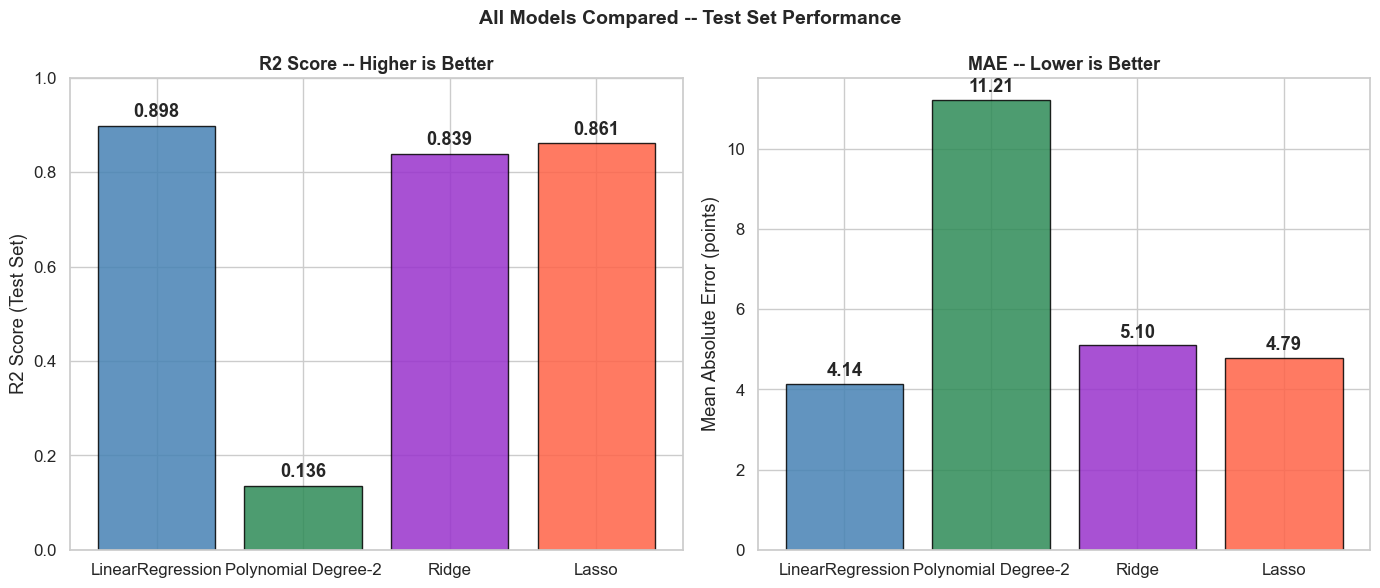

In [186]:
# ── Bar chart comparison — all models ────────────────────────────────────

models_names = ['LinearRegression', 'Polynomial Degree-2', 'Ridge', 'Lasso']
r2_test_vals = [r2, r2_poly, r2_ridge, r2_lasso]
mae_vals     = [mae, mae_poly, mae_ridge, mae_lasso]
colors       = ['steelblue', 'seagreen', 'darkorchid', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R2 comparison
bars1 = axes[0].bar(models_names, r2_test_vals, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('R2 Score -- Higher is Better', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R2 Score (Test Set)')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, r2_test_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# MAE comparison
bars2 = axes[1].bar(models_names, mae_vals, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('MAE -- Lower is Better', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (points)')
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('All Models Compared -- Test Set Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


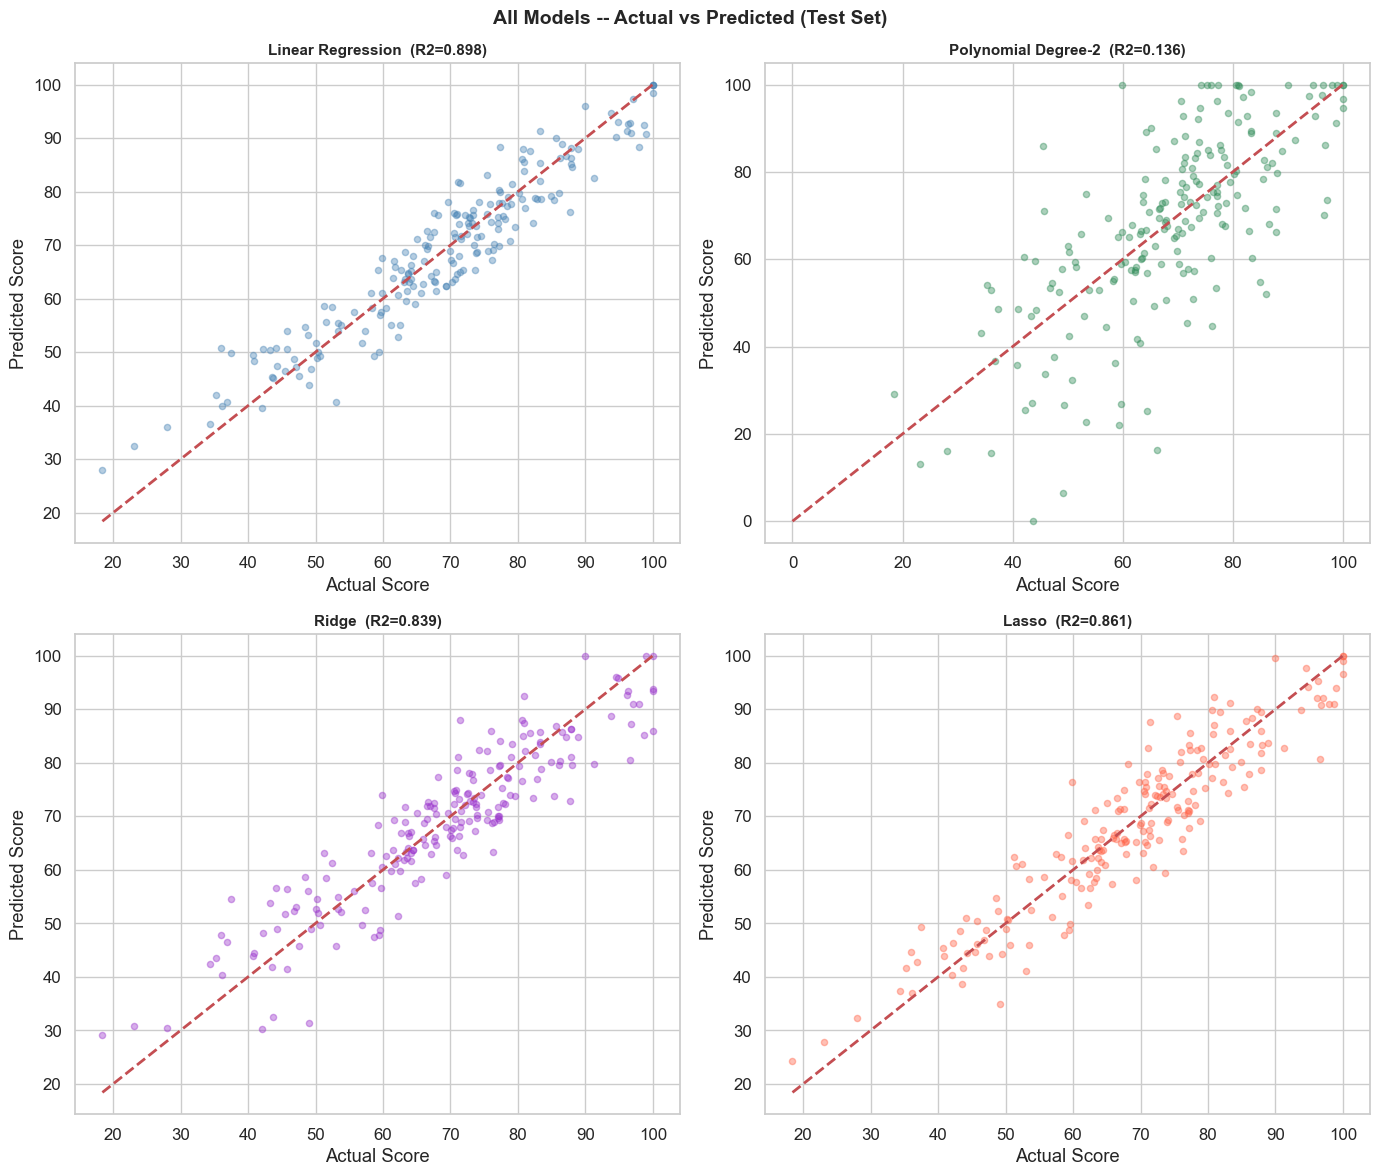

In [187]:
# ── Actual vs Predicted for all 4 models in one figure ──────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

configs = [
    (y_pred,       'steelblue',   f'Linear Regression  (R2={r2:.3f})'),
    (y_pred_poly,  'seagreen',    f'Polynomial Degree-2  (R2={r2_poly:.3f})'),
    (y_pred_ridge, 'darkorchid',  f'Ridge  (R2={r2_ridge:.3f})'),
    (y_pred_lasso, 'tomato',      f'Lasso  (R2={r2_lasso:.3f})'),
]

for ax, (preds, color, title) in zip(axes, configs):
    ax.scatter(y_test, preds, alpha=0.4, s=20, color=color)
    mn = min(y_test.min(), preds.min())
    mx = max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Score')
    ax.set_ylabel('Predicted Score')

plt.suptitle('All Models -- Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Updated Summary — What You Learned
---

## Regression Models — When to Use What

| Model | Best Used When | Key Idea |
|-------|---------------|----------|
| **Linear Regression** | Relationships look like straight lines | Simple, fast, interpretable |
| **Polynomial Regression** | Relationships are curved | Adds x^2, x^3 terms to capture curves |
| **Ridge Regression** | Many features, risk of overfitting | Penalises large weights (keeps all features smaller) |
| **Lasso Regression** | Many features, some may be irrelevant | Penalises weights, zeros out useless ones (feature selection) |

---

## Encoding — When to Use What

| Encoding | Best Used When | Example |
|----------|---------------|---------|
| **One-Hot Encoding** | Categories have no natural order | Gender, Part-time job |
| **Ordinal Encoding** | Categories have a meaningful rank | Diet quality (Poor < Fair < Good) |

---

## Key Terms to Remember

- **Overfitting** — Model does well on training data but poorly on new data
- **Regularization** — Adding a penalty to prevent overfitting (Ridge and Lasso do this)
- **Alpha** — Controls how strong the penalty is; higher alpha = simpler model
- **Feature Selection** — Automatically choosing which features to keep (Lasso does this)
- **Degree** — In polynomial regression, which powers of x to create

---

## The ML Workflow You Now Know

```
1. Load and Explore Data
2. Clean Data
3. Visualise
4. Encode Categorical Features (One-Hot or Ordinal)
5. Split (Train / Test)
6. Scale Features
7. Train Models (Linear, Polynomial, Ridge, Lasso)
8. Evaluate (MAE, RMSE, R2)
9. Compare and Choose Best Model
10. Predict New Students
```

---
